# Visualizing the difference between geodesic and tangent PCA

In this example, we compare Bures-Wasserstein geodesic PCA and tangent PCA on a set of SPD matrices that are displayed on two intersecting geodesics.

In [1]:
import os
import sys
from pathlib import Path
sys.path.append(str(Path(os.getcwd()).parent.absolute()))

In [3]:
import numpy as np

from pca.bures_wasserstein_principal_geodesic_analysis import BuresWassersteinPGA
from pca.bures_wasserstein_tangent_pca import BuresWassersteinTPCA
from tools.generate import generate_spd_matrices_on_intersecting_geodesics
from tools.plot_2d import plot_results_compare

INFO: Using numpy backend


In order to easily visualize the SPD matrices as ellipses in the plane, we set the dimension to 2, i.e. we consider SPD matrices of size $2\times 2$, representing the covariance matrices of centered Gaussian distributions on the plane. We randomly generate two intersecting geodesics in the space of SPD matrices for the Bures-Wasserstein metric, and sample `n_times` points on these geodesics between `-time` and `time`.

In [4]:
dim = 2
np.random.seed(1)
points_spd, mean, curv = generate_spd_matrices_on_intersecting_geodesics(dim=dim, n_times=10, time=1)

We perform geodesic PCA and tangent PCA on these SPD matrices,

In [5]:
res_tpca = BuresWassersteinTPCA.fit(points_spd)
res_pga = BuresWassersteinPGA(dim=2).fit(points_spd)

and compute the change of cost for the first two components.

In [6]:
ratio_cost_1 = (res_tpca['cost_1'] - res_pga['cost_1']) / res_tpca['cost_1']
ratio_cost_2 = (res_tpca['cost_2'] - res_pga['cost_2']) / res_tpca['cost_2']

word_1 = 'smaller' if ratio_cost_1 > 0. else 'greater'
word_2 = 'smaller' if ratio_cost_2 > 0. else 'greater'

print(f'The component 1 cost is {np.around(ratio_cost_1 * 100, 1)} percent {word_1} for PGA than for TPCA.')
print(f'The component 2 cost is {np.around(ratio_cost_2 * 100, 1)} percent {word_2} for PGA than for TPCA.')

The component 1 cost is 1.7 percent smaller for PGA than for TPCA.
The component 2 cost is 4.7 percent smaller for PGA than for TPCA.



Finally, we plot the results. Each SPD matrix is represented by the image of the circle by the linear transformation of the plane induced by the matrix. The initial points (SPD matrices) are in blue and magenta, each color corresponding to one geodesic. We plot in dashed lines their projections on the first and second component.

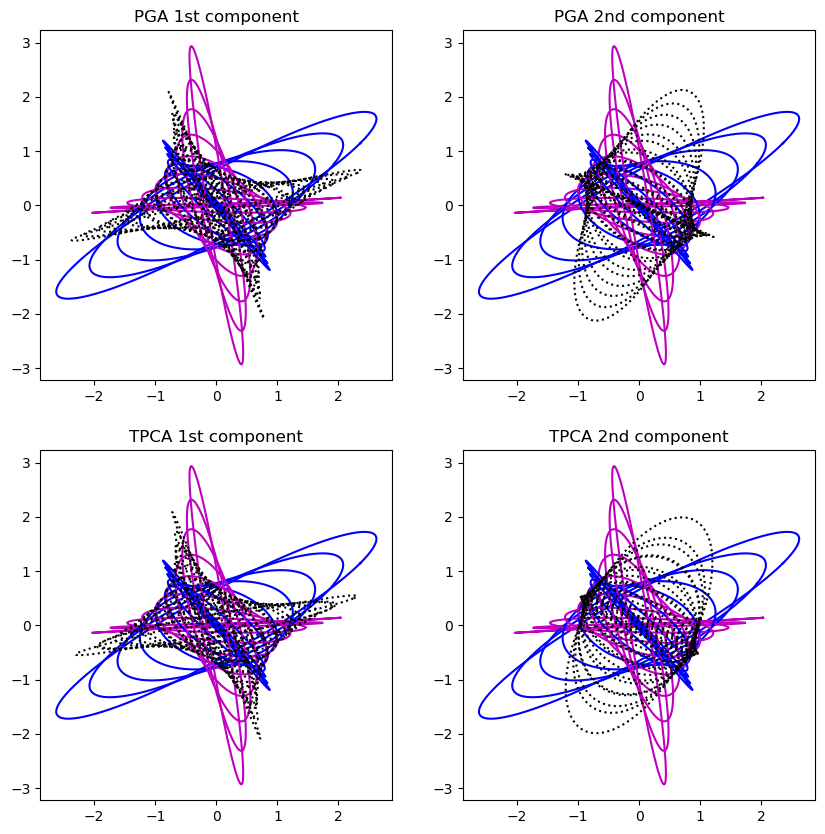

In [7]:
plot_results_compare(points_spd, res_pga, res_tpca)

Finally, we can visualize an example where the improvement of either cost is more than a given threshold with the following code. To obtain an improvement of at least 10%, set `threshold=0.1`.

In [8]:
def compare_pga_and_tpca_on_intersecting_geodesics(time=1., n_times=10, n_max_iter=100, threshold=0., seed=None):
    dim = 2
    if seed is not None: np.random.seed(1)

    iteration = 0.
    while iteration < n_max_iter:
        points_spd, mean, curv = generate_spd_matrices_on_intersecting_geodesics(dim=dim, n_times=n_times, time=time)

        res_tpca = BuresWassersteinTPCA.fit(points_spd)
        res_pga = BuresWassersteinPGA(dim=2).fit(points_spd)

        ratio_cost_1 = (res_tpca['cost_1'] - res_pga['cost_1']) / res_tpca['cost_1']
        ratio_cost_2 = (res_tpca['cost_2'] - res_pga['cost_2']) / res_tpca['cost_2']

        if ratio_cost_1 > threshold or ratio_cost_2 > threshold:
            print(f'The component 1 cost is {np.around(ratio_cost_1 * 100, 1)} percent less for PGA than for TPCA.')
            print(f'The component 2 cost is {np.around(ratio_cost_2 * 100, 1)} percent less for PGA than for TPCA.')
            print('')
            plot_results_compare(points_spd, res_pga, res_tpca)
            break

        iteration += 1

    if iteration == n_max_iter:
        print("No results found for the desired threshold and maximum number of iterations.")

The component 1 cost is 1.4 percent less for PGA than for TPCA.
The component 2 cost is 34.9 percent less for PGA than for TPCA.



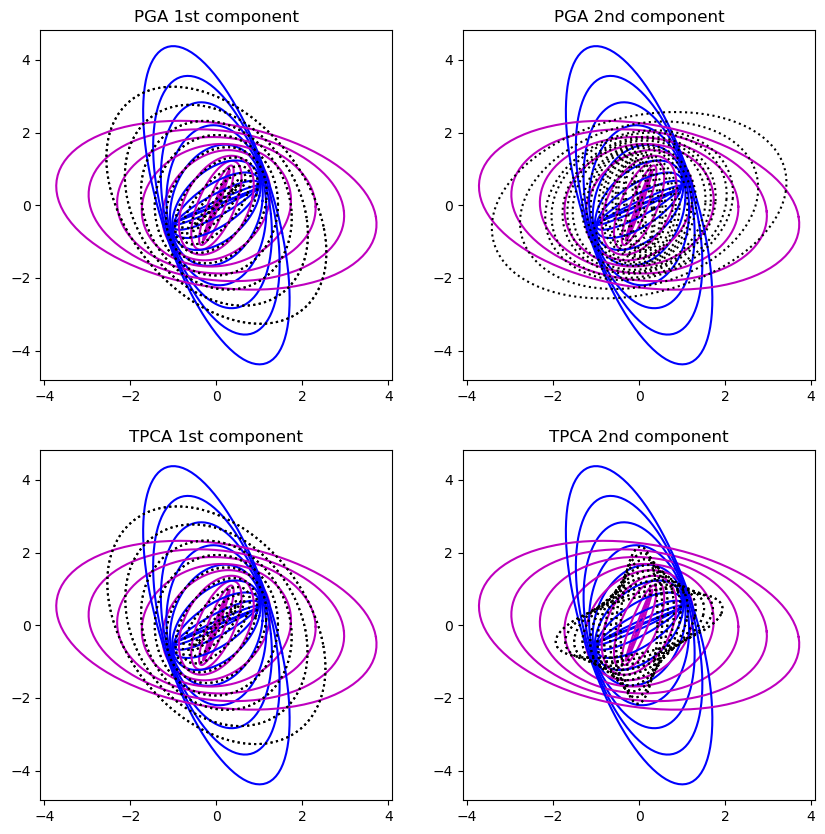

In [9]:
compare_pga_and_tpca_on_intersecting_geodesics(time=1., threshold=0.1, seed=1)